In [1]:
from zipfile import ZipFile
from torch.utils.data import Dataset, DataLoader

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init

In [133]:
from torchmetrics import Accuracy, Precision, Recall, F1Score

In [77]:
# For CNN
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [12]:
from ydf import RandomForestLearner

In [2]:
from startup import np, pd, Path, smf, plt, sns

In [72]:
data_dir = Path.home() / 'Work' / 'Data' / 'datacamp_intermediate_pytorch'
data_file = data_dir / 'water_potability.zip'
zip_file = ZipFile(data_file)
dfs = {
    csv_file.filename.split('/')[1].rstrip('.csv').split('_')[1]: pd.read_csv(zip_file.open(csv_file.filename), encoding='ISO-8859-1')
    for csv_file in zip_file.infolist() if csv_file.filename.endswith('csv') and not csv_file.filename.startswith('__')
}

For reference try a Random Forest and use to determine variable importance

In [24]:
model = RandomForestLearner(label='Potability').train(dfs['train'])

Train model on 1508 examples
Model trained in 0:00:00.129728


In [63]:
evaluation = model.evaluate(dfs['test'])
print(f'ROC AUC: {evaluation.characteristics[0].roc_auc:0.2f}, Accuracy {evaluation.accuracy:0.2f}')

ROC AUC: 0.70, Accuracy 0.69


In [22]:
model.variable_importances()['INV_MEAN_MIN_DEPTH']

[(0.32502872236531766, 'Sulfate'),
 (0.28721388517062846, 'ph'),
 (0.19480933269471062, 'Hardness'),
 (0.1451010825279234, 'Chloramines'),
 (0.1391793132318984, 'Solids'),
 (0.12797646638764243, 'Turbidity'),
 (0.11755855369314434, 'Organic_carbon'),
 (0.11720859736447167, 'Trihalomethanes'),
 (0.1133190327156745, 'Conductivity')]

Back to PyTorch - define dataset and data loader

In [47]:
class WaterDataset(Dataset):
    def __init__(self, df : pd.DataFrame):
        self.data = df.to_numpy()

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, item):
        features = self.data[item, :-1]
        label = self.data[item, -1]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

In [48]:
dataset_train = WaterDataset(dfs['train'])

In [49]:
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

In [59]:
dataloader_test = DataLoader(WaterDataset(dfs['test']), batch_size=32, shuffle=False)

In [50]:
n_features = dataset_train[0][0].shape[0]
layer_sizes = [n_features, 16, 8]

Model Definition

In [65]:
class Net(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        self.fc1 = nn.Linear(layer_sizes[0], layer_sizes[1])
        self.fc2 = nn.Linear(layer_sizes[1], layer_sizes[2])
        self.fc3 = nn.Linear(layer_sizes[2], 1)
        # Added later
        self._init_weights()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        return x

    def _init_weights(self):
        # Added later
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity='sigmoid')

In [66]:
net = Net(layer_sizes)

In [67]:
for param in net.named_parameters():
    print(param[0], '\t', param[1].shape)

fc1.weight 	 torch.Size([16, 9])
fc1.bias 	 torch.Size([16])
fc2.weight 	 torch.Size([8, 16])
fc2.bias 	 torch.Size([8])
fc3.weight 	 torch.Size([1, 8])
fc3.bias 	 torch.Size([1])


Loss Function and Optimizer

In [68]:
criterion = nn.BCELoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

Training Loop

In [69]:
for epoch in range(1000):
    for features, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(features)
        loss = criterion(outputs, labels.view(-1, 1))
        loss.backward()
        optimizer.step()

Model Evaluation

In [70]:
acc = Accuracy(task='binary')

net.eval()

with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        preds = (outputs > 0.5).float()
        acc(preds, labels.view(-1, 1))

In [71]:
accuracy = acc.compute()
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.66


Weight Initialization

See "Added Later" sections of model, as this is covered in the last part of Ch1 video.

He / Kaiming initialisation is designed to keep variances of inputs and outputs the same, as well as gradients.

# Convolutional Neural Networks

In [73]:
data_file_img = data_dir / 'clouds.zip'
zip_file_img = ZipFile(data_file_img)

In [89]:
if (data_dir / 'clouds').is_dir():
    print('Directory exists')
else:
    print('Extracting...')
    zip_file_img.extractall(data_dir)

Directory exists


In [138]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=45),
    transforms.RandomAutocontrast(),
    # transforms.CenterCrop(64),  # Thought cropping might help by removing black regions of rotated images but not so much
    transforms.ToTensor(),
    transforms.Resize((64, 64))
])

In [139]:
dataset_train_img = ImageFolder(data_dir / 'clouds' / 'clouds_train', transform=train_transforms)

In [140]:
dataloader_train_img = DataLoader(
    dataset_train_img, batch_size=32, shuffle=True
)

In [141]:
features, labels = next(iter(dataloader_train_img))

In [142]:
features.shape

torch.Size([32, 3, 64, 64])

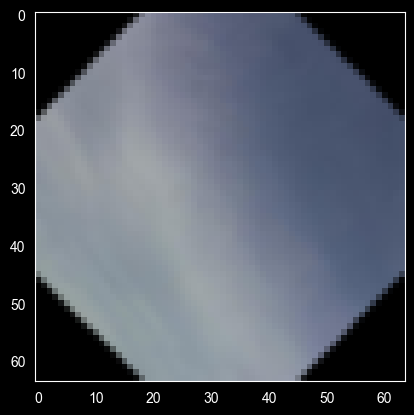

In [143]:
ax = plt.imshow(features[1].permute(1, 2, 0))
plt.grid(None)

In [144]:
class CnnNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        self.classifier = nn.Linear(64*16*16, n_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [145]:
net_img = CnnNet(n_classes=7)

In [146]:
criterion_img = nn.CrossEntropyLoss()
optimizer_img = optim.Adam(net_img.parameters(), lr=0.001)

In [147]:
for epoch in range(10):
    running_loss = 0.0
    for features, labels in dataloader_train_img:
        optimizer_img.zero_grad()
        outputs = net_img(features)
        loss = criterion_img(outputs, labels)
        loss.backward()
        optimizer_img.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader_train_img)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 2.0706
Epoch 2, Loss: 1.6348
Epoch 3, Loss: 1.4405
Epoch 4, Loss: 1.3899
Epoch 5, Loss: 1.3688
Epoch 6, Loss: 1.3999
Epoch 7, Loss: 1.2932
Epoch 8, Loss: 1.2497
Epoch 9, Loss: 1.1623
Epoch 10, Loss: 1.1434


In [148]:
test_transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize((64, 64)),
    ]
)

In [149]:
dataset_test_img = ImageFolder(
    data_dir / 'clouds' / 'clouds_test', transform=test_transforms
)

In [150]:
dataloader_test_img = DataLoader(
    dataset_test_img, batch_size=32, shuffle=False
)

In [155]:
average_method = 'macro'
metric_precision = Precision(
    task='multiclass', num_classes=7, average=average_method
)
metric_recall = Recall(
    task='multiclass', num_classes=7, average=average_method
)
metric_f1score = F1Score(
    task='multiclass', num_classes=7, average=average_method
)
# Per class
metric_precision_pc = Precision(
    task='multiclass', num_classes=7, average=None
)

In [156]:
net_img.eval()
with torch.no_grad():
    for features, labels in dataloader_test_img:
        outputs = net_img(features)
        _, preds = torch.max(outputs, dim=1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)
        metric_f1score(preds, labels)
        metric_precision_pc(preds, labels)

In [158]:
precision = metric_precision.compute()
recall = metric_recall.compute()
f1score = metric_f1score.compute()
precision_pc = metric_precision_pc.compute()

In [159]:
print(f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1score:.2f}')

Precision: 0.57, Recall: 0.55, F1 Score: 0.51


In [160]:
# Get precision per class
precision_per_class = {
    k: precision_pc[v].item()
    for k, v
    in dataset_test_img.class_to_idx.items()
}
print(precision_per_class)

{'cirriform clouds': 0.0, 'clear sky': 0.8399999737739563, 'cumulonimbus clouds': 0.7142857313156128, 'cumulus clouds': 0.5537189841270447, 'high cumuliform clouds': 0.36036035418510437, 'stratiform clouds': 1.0, 'stratocumulus clouds': 0.4878048896789551}
